In [4]:
# ==========================================
# CELL 1: Installations & Environment Setup
# ==========================================
# 1. Install the modern Hugging Face ecosystem
# (Colab usually has torch and numpy pre-installed)
!pip install -q transformers datasets evaluate accelerate

# 2. Import standard libraries
import time
import datetime
import random
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 3. Import Hugging Face and PyTorch utilities
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# 4. Set Random Seeds for Reproducibility
# This guarantees that the random initialization of the models and the shuffling
# of the data happen exactly the same way every time you run this script.
def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_val)

set_seed(42)
print("Random seeds set for reproducibility.")

# 5. Connect to the GPU
# PyTorch requires us to explicitly move data and models to the GPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"There are {torch.cuda.device_count()} GPU(s) available.")
    print(f"We will use the GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU available, using the CPU instead. Training will be very slow!")
    device = torch.device("cpu")

Random seeds set for reproducibility.
There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [5]:
# ==========================================
# CELL 2: 3-Way Split (Train / Val / Test)
# ==========================================

print("Loading custom dataset and creating 3-way split...")

# 1. Load your local CSV file
raw_datasets = load_dataset("csv", data_files="/content/TrainingSet_Binary_Perfect_4100.csv")
# --- STRATIFICATION UPGRADE ---
# 1.5. Tell Hugging Face that the "label" column represents classification classes.
raw_datasets = raw_datasets.class_encode_column("stratify_key")

# 2. First split: 80% Train, 20% Temporary (Val + Test)
train_temp_split = raw_datasets["train"].train_test_split(test_size=0.2, seed=42, stratify_by_column="stratify_key")

# 3. Second split: Split the 20% into half Validation (10%) and half Test (10%)
val_test_split = train_temp_split["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="stratify_key")

# 4. Re-combine into a single DatasetDict with all 3 splits
from datasets import DatasetDict

final_datasets = DatasetDict({
    "train": train_temp_split["train"],
    "validation": val_test_split["train"],
    "test": val_test_split["test"]
})

print("--- Dataset Splits ---")
print(f"Train samples:      {len(final_datasets['train']):,}")
print(f"Validation samples: {len(final_datasets['validation']):,}")
print(f"Test samples:       {len(final_datasets['test']):,}")

# 5. Define tokenization function (using the max_length you decided on)
# Replace MAX_LEN with the value from your Cell 2.5 analysis!
MAX_LEN = 256

def tokenize_function(examples, tokenizer):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False # Dynamic padding will be handled per-batch later
    )

print("\nData ready with proper 3-way split!")

Loading custom dataset and creating 3-way split...
--- Dataset Splits ---
Train samples:      6,560
Validation samples: 820
Test samples:       820

Data ready with proper 3-way split!


--- Class Distribution Verification ---
Train      | Class 0: 3,280 samples (50.0%)
Train      | Class 1: 3,280 samples (50.0%)
Validation | Class 0: 410 samples (50.0%)
Validation | Class 1: 410 samples (50.0%)
Test       | Class 0: 410 samples (50.0%)
Test       | Class 1: 410 samples (50.0%)

--- Sequence Length Analysis (All Data) ---


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/6560 [00:00<?, ? examples/s]

Map:   0%|          | 0/820 [00:00<?, ? examples/s]

Map:   0%|          | 0/820 [00:00<?, ? examples/s]

Total samples measured: 8,200
Max observed token length: 192
90% of samples are <= 54 tokens
95% of samples are <= 72 tokens
99% of samples are <= 91 tokens


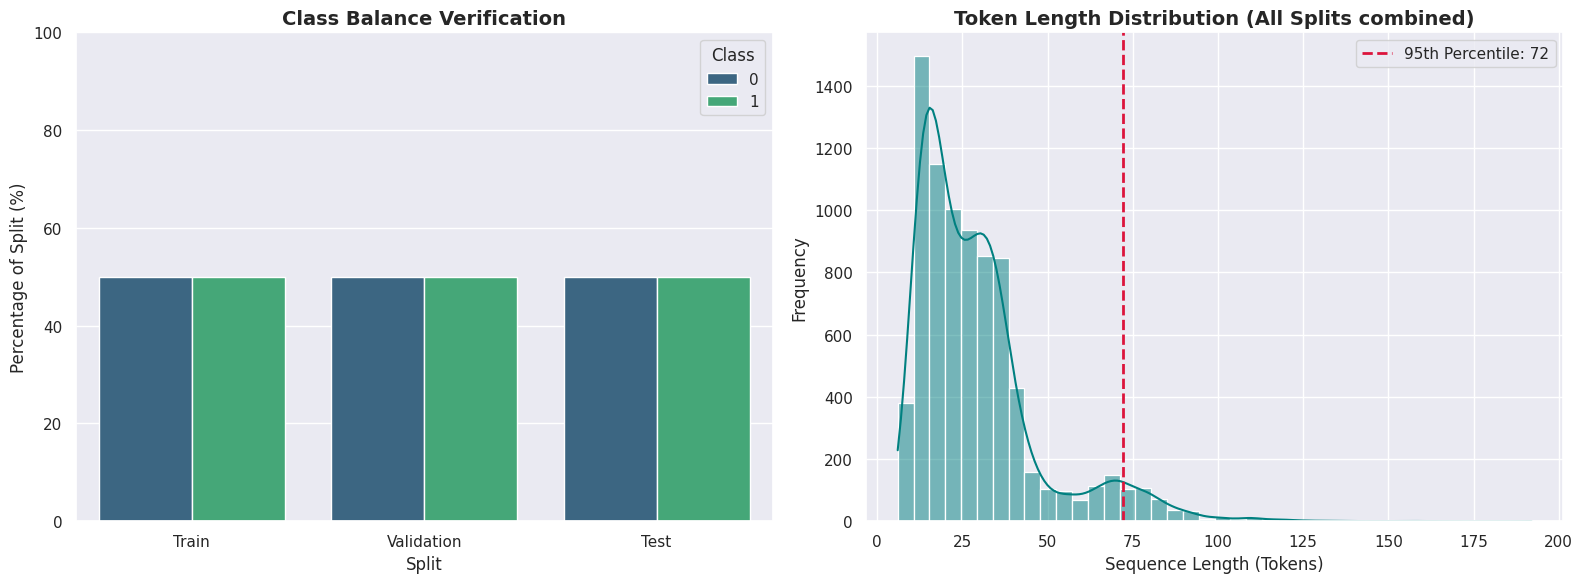

In [6]:
# ==========================================================
# ULTIMATE CELL 2.5: Rigorous EDA
# 1. Verify Stratification across ALL splits
# 2. Sequence Length Distribution (Across ALL data)
# ==========================================================

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Part 1: Verify Class Balance Across All Splits
# ---------------------------------------------------------
print("--- Class Distribution Verification ---")
distribution_data = []

# Loop through all splits to calculate percentages
for split in ["train", "validation", "test"]:
    labels = final_datasets[split]["label"]
    unique_labels, counts = np.unique(labels, return_counts=True)

    for label, count in zip(unique_labels, counts):
        pct = (count / len(labels)) * 100
        distribution_data.append({"Split": split.capitalize(), "Class": label, "Count": count, "Percentage": pct})
        print(f"{split.capitalize():<10} | Class {label}: {count:,} samples ({pct:.1f}%)")

# Plot Grouped Bar Chart for Class Balance
df_dist = pd.DataFrame(distribution_data)
sns.barplot(data=df_dist, x="Split", y="Percentage", hue="Class", ax=axes[0], palette="viridis")
axes[0].set_title('Class Balance Verification', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage of Split (%)', fontsize=12)
axes[0].set_ylim(0, 100)

# ---------------------------------------------------------
# Part 2: Sequence Length Analysis (Entire Dataset)
# ---------------------------------------------------------
print("\n--- Sequence Length Analysis (All Data) ---")
temp_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def get_lengths(batch):
    return {"length": [len(x) for x in temp_tokenizer(batch["text"])["input_ids"]]}

all_lengths = []
# Map over train, val, and test to gather EVERY length
for split in ["train", "validation", "test"]:
    lengths_dataset = final_datasets[split].map(get_lengths, batched=True)
    all_lengths.extend(lengths_dataset["length"])

# Calculate key percentiles across the whole dataset
p90 = np.percentile(all_lengths, 90)
p95 = np.percentile(all_lengths, 95)
p99 = np.percentile(all_lengths, 99)
max_len_observed = max(all_lengths)

print(f"Total samples measured: {len(all_lengths):,}")
print(f"Max observed token length: {max_len_observed}")
print(f"90% of samples are <= {p90:.0f} tokens")
print(f"95% of samples are <= {p95:.0f} tokens")
print(f"99% of samples are <= {p99:.0f} tokens")

# Plot Sequence Length Distribution
sns.histplot(all_lengths, bins=40, kde=True, ax=axes[1], color='teal')
axes[1].axvline(p95, color='crimson', linestyle='--', linewidth=2, label=f'95th Percentile: {p95:.0f}')
axes[1].set_title('Token Length Distribution (All Splits combined)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sequence Length (Tokens)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# CELL 3: The Reusable PyTorch Training Engine
# ==========================================================

# Helper function to format time as hh:mm:ss
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

def train_and_evaluate(model, train_dataloader, val_dataloader, epochs=3, learning_rate=2e-5):
    """
    A robust PyTorch training loop that handles backpropagation, optimization,
    and validation evaluation.
    """
    print(f"Starting training on device: {device}")

    # 1. Setup Optimizer and Scheduler
    # We use AdamW. The learning rate is kept very small for fine-tuning.
    optimizer = AdamW(model.parameters(), lr=learning_rate, eps=1e-6)

    total_steps = len(train_dataloader) * epochs

    # The scheduler linearly decreases the learning rate over time
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1), # Warm up for the first 10% of steps
        num_training_steps=total_steps
    )

    # Store metrics to plot and compare later
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    # --- CHECKPOINTING VARIABLES ---
    best_val_f1 = 0.0
    best_val_loss = float('inf') # Infinity, because we want loss to go DOWN
    best_model_weights = None
    min_delta = 0.005

    for epoch_i in range(epochs):
        print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")
        t0 = time.time()

        # ========================================
        #               Training
        # ========================================
        model.train() # Put model in training mode (turns on Dropout)
        total_train_loss = 0

        for step, batch in enumerate(train_dataloader):
            # Move batch data to the GPU
            b_input_ids = batch['input_ids'].to(device)
            b_input_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)

            # Step 1: Clear old gradients
            model.zero_grad()

            # Step 2: Forward pass (make a guess and calculate loss)
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss
            total_train_loss += loss.item()

            # Step 3: Backward pass (calculate exactly how wrong the dials are)
            loss.backward()

            # Step 4: Clip the gradients to prevent them from exploding (limit to 1.0)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Step 5: Update the weights and adjust the learning rate
            optimizer.step()
            scheduler.step()

            # Print progress every 50 batches
            if step % 50 == 0 and not step == 0:
                elapsed = format_time(time.time() - t0)
                print(f"  Batch {step:>5,}  of  {len(train_dataloader):>5,}.    Elapsed: {elapsed}.")

        avg_train_loss = total_train_loss / len(train_dataloader)
        training_time = format_time(time.time() - t0)
        print(f"  Average Training Loss: {avg_train_loss:.4f} | Time: {training_time}")
        history['train_loss'].append(avg_train_loss)

        # ========================================
        #               Validation
        # ========================================
        print("  Running Validation...")
        t0 = time.time()

        model.eval() # Put model in test mode (turns off Dropout)
        total_val_loss = 0
        all_preds = []
        all_true = []

        for batch in val_dataloader:
            b_input_ids = batch['input_ids'].to(device)
            b_input_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)

            # torch.no_grad() tells PyTorch NOT to save the math for backpropagation.
            # This makes validation much faster and uses way less memory.
            with torch.no_grad():
                outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

            total_val_loss += outputs.loss.item()

            # Move outputs back to CPU so we can use standard Python math on them
            logits = outputs.logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            # Convert raw logits to 0 or 1 predictions using argmax
            preds = np.argmax(logits, axis=1).flatten()

            all_preds.extend(preds)
            all_true.extend(label_ids)

        # Calculate final metrics for the epoch
        avg_val_loss = total_val_loss / len(val_dataloader)
        val_accuracy = accuracy_score(all_true, all_preds)

        # We use 'macro' F1-score to equally weight both classes
        val_f1 = f1_score(all_true, all_preds, average='macro')

        validation_time = format_time(time.time() - t0)
        print(f"  Validation Loss: {avg_val_loss:.4f} | Acc: {val_accuracy:.4f} | F1: {val_f1:.4f} | Time: {validation_time}")

        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)
        history['val_f1'].append(val_f1)

        # --- INSIDE THE VALIDATION LOOP (After computing val_loss & val_f1) ---
        # Primary condition: Significant drop in validation loss
        # Secondary tie-breaker: Better F1 when loss is stable
        loss_improved = (best_val_loss - avg_val_loss) > min_delta
        f1_improved = (val_f1 - best_val_f1) > min_delta

        if loss_improved or (abs(avg_val_loss - best_val_loss) <= min_delta and f1_improved):
            best_val_loss = avg_val_loss
            best_val_f1 = max(val_f1, best_val_f1)
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"  🌟 New best model found! Saving weights (F1: {best_val_f1:.4f}, Loss: {best_val_loss:.4f})...")

    # --- RESTORE THE BEST MODEL ---
    print(f"\nTraining complete! Restoring the best weights with F1: {best_val_f1:.4f}")
    model.load_state_dict(best_model_weights)

    print("\nTraining complete!")
    return history

In [8]:
# ==========================================================
# CELL 4: Data Preparation & Smart Batching (DataLoaders)
# ==========================================================

# Make sure this matches the 95th percentile from your Cell 2.5 EDA!
MAX_LEN = 400
BATCH_SIZE = 16

def prepare_dataloaders(model_checkpoint, dataset_dict):
    """
    Downloads the correct tokenizer, tokenizes the text, and wraps everything
    in PyTorch DataLoaders with dynamic Smart Batching.
    """
    print(f"\n[ Preparing Data Pipeline for: {model_checkpoint} ]")

    # 1. Load the specific tokenizer for this model
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    # 2. Define the tokenization behavior
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=MAX_LEN,
            padding=False # <-- We still do NOT pad here!
        )

    # Apply tokenization to Train, Val, and Test splits
    tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

    # 3. Clean up for PyTorch
    # PyTorch tensors can only hold numbers. If we leave the raw string "text"
    # column in the dataset, the DataLoader will crash.
    tokenized_datasets = tokenized_datasets.remove_columns(["text", "domain", "stratify_key"])

    # Hugging Face models specifically look for a column named "labels" (plural)
    if "label" in tokenized_datasets["train"].column_names:
        tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

    tokenized_datasets.set_format("torch")

    # ==========================================
    # 4. SMART BATCHING: DataCollatorWithPadding
    # ==========================================
    # This single line of code replaces the entire manual batching script from the article.
    # It watches the DataLoader. When the DataLoader grabs 16 random reviews,
    # this collator looks at them, finds the longest one, and pads the other 15 to match it.
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # 5. Create PyTorch DataLoaders
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        shuffle=True, # Randomize for training to prevent catastrophic forgetting
        batch_size=BATCH_SIZE,
        collate_fn=data_collator # Inject the smart batching logic here!
    )

    val_dataloader = DataLoader(
        tokenized_datasets["validation"],
        batch_size=BATCH_SIZE,
        collate_fn=data_collator
    )

    test_dataloader = DataLoader(
        tokenized_datasets["test"],
        batch_size=BATCH_SIZE,
        collate_fn=data_collator
    )

    print("  DataLoaders created successfully with Smart Batching enabled.")
    return train_dataloader, val_dataloader, test_dataloader, tokenizer

In [9]:
# ==========================================
# QUICK FIX: Patch the torchvision bug
# ==========================================
import torchvision

# Create a fake, empty class
class DummyVideoReader:
    pass

# Shove it into torchvision so Hugging Face stops crashing
torchvision.io.VideoReader = DummyVideoReader

print("Framework bug patched! You are good to go.")

Framework bug patched! You are good to go.


In [10]:
# ==========================================================
# CELL 5: The Model Tournament (Training Loop)
# ==========================================================

# 1. Define the competitors
# We use small/base versions to ensure they train in a reasonable time on a T4 GPU.
models_to_test = [
    "bert-base-uncased",
    "roberta-base",
    "microsoft/deberta-v3-small",
    "google/electra-base-discriminator",
    "distilbert-base-uncased",
    "albert-base-v2",
    "answerdotai/ModernBERT-base"
]

# We need to tell the models how many output classes to expect.
# For binary classification (Positive/Negative), it's 2.
NUM_LABELS = len(set(final_datasets["train"]["label"]))

# Dictionary to store the history of each model for plotting later
tournament_results = {}
trained_models = {}

for checkpoint in models_to_test:
    print("\n" + "="*50)
    print(f" INITIALIZING MODEL: {checkpoint}")
    print("="*50)

    # Step A: Prepare the data pipelines (Smart Batching)
    # We call our reusable function from Cell 4
    train_dl, val_dl, test_dl, tokenizer = prepare_dataloaders(checkpoint, final_datasets)

    # Step B: Load the Pre-trained Model
    # We use AutoModelForSequenceClassification. This grabs the base brain and
    # slaps a randomly initialized linear classification head on top.
    print(f"  Downloading/Loading {checkpoint} into memory...")
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=NUM_LABELS,
        # DeBERTa has a known warning about dropout we can silence here
        ignore_mismatched_sizes=True
    )

    # Move the model to the GPU
    model.to(device)

    # Step C: Train and Evaluate!
    # We call our reusable engine from Cell 3.
    # 3 epochs is usually the sweet spot for fine-tuning encoder models.
    history = train_and_evaluate(
        model=model,
        train_dataloader=train_dl,
        val_dataloader=val_dl,
        epochs=5,
        learning_rate=1e-5
    )

    # Step D: Save the results for comparison
    tournament_results[checkpoint] = history

    # We keep the trained model in a dictionary so we can grab the winner later
    # to evaluate on the test set.
    trained_models[checkpoint] = model

    print(f"\n[Finished training {checkpoint}]")

print("\n\n🏆 TOURNAMENT COMPLETE! 🏆")
print("All models have been fine-tuned and validated. Proceed to Cell 6 to analyze the results.")


 INITIALIZING MODEL: bert-base-uncased

[ Preparing Data Pipeline for: bert-base-uncased ]


Map:   0%|          | 0/6560 [00:00<?, ? examples/s]

Map:   0%|          | 0/820 [00:00<?, ? examples/s]

Map:   0%|          | 0/820 [00:00<?, ? examples/s]

  DataLoaders created successfully with Smart Batching enabled.
  Downloading/Loading bert-base-uncased into memory...


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training on device: cuda

======== Epoch 1 / 5 ========
  Batch    50  of    410.    Elapsed: 0:00:18.
  Batch   100  of    410.    Elapsed: 0:00:34.
  Batch   150  of    410.    Elapsed: 0:00:51.
  Batch   200  of    410.    Elapsed: 0:01:07.
  Batch   250  of    410.    Elapsed: 0:01:22.
  Batch   300  of    410.    Elapsed: 0:01:39.
  Batch   350  of    410.    Elapsed: 0:01:57.
  Batch   400  of    410.    Elapsed: 0:02:13.
  Average Training Loss: 0.4247 | Time: 0:02:16
  Running Validation...
  Validation Loss: 0.3171 | Acc: 0.8402 | F1: 0.8401 | Time: 0:00:06
  🌟 New best model found! Saving weights (F1: 0.8401, Loss: 0.3171)...

======== Epoch 2 / 5 ========
  Batch    50  of    410.    Elapsed: 0:00:17.
  Batch   100  of    410.    Elapsed: 0:00:33.
  Batch   150  of    410.    Elapsed: 0:00:50.
  Batch   200  of    410.    Elapsed: 0:01:07.
  Batch   250  of    410.    Elapsed: 0:01:24.
  Batch   300  of    410.    Elapsed: 0:01:40.
  Batch   350  of    410.    Elaps

🏆 TOURNAMENT WINNER: distilbert-base-uncased 🏆
Winning Validation F1-Score: 0.8780


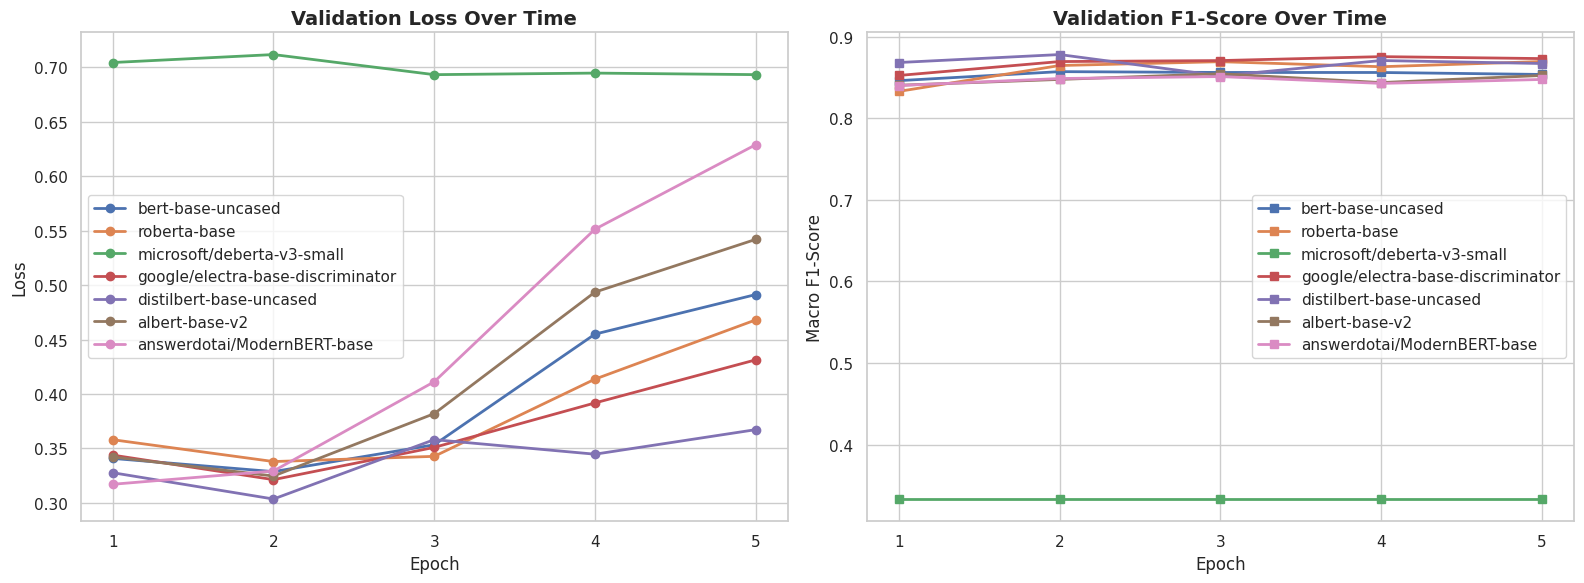


[ Running Final Exam on the Test Set using distilbert-base-uncased ]

[ Preparing Data Pipeline for: distilbert-base-uncased ]


Map:   0%|          | 0/820 [00:00<?, ? examples/s]

  DataLoaders created successfully with Smart Batching enabled.

 FINAL TEST SET RESULTS (distilbert-base-uncased)
Test Accuracy: 0.8720
Test F1-Score: 0.8719

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       410
           1       0.86      0.89      0.87       410

    accuracy                           0.87       820
   macro avg       0.87      0.87      0.87       820
weighted avg       0.87      0.87      0.87       820



In [11]:
# ==========================================================
# CELL 6: Tournament Results & Final Evaluation
# ==========================================================

sns.set_theme(style='whitegrid')

# 1. Extract the final Validation F1 scores to find the winner
final_scores = {}
for model_name, history in tournament_results.items():
    # Grab the F1 score from the final epoch
    final_scores[model_name] = max(history['val_f1'])

# Crown the winner
winner_name = max(final_scores, key=final_scores.get)
print("="*50)
print(f"🏆 TOURNAMENT WINNER: {winner_name} 🏆")
print(f"Winning Validation F1-Score: {final_scores[winner_name]:.4f}")
print("="*50)

# 2. Plot the Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, history in tournament_results.items():
    epochs = range(1, len(history['val_loss']) + 1)

    # Left Plot: Validation Loss (Lower is better)
    axes[0].plot(epochs, history['val_loss'], marker='o', label=model_name, linewidth=2)

    # Right Plot: Validation F1 Score (Higher is better)
    axes[1].plot(epochs, history['val_f1'], marker='s', label=model_name, linewidth=2)

axes[0].set_title('Validation Loss Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)
axes[0].legend()

axes[1].set_title('Validation F1-Score Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1-Score')
axes[1].set_xticks(epochs)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================================
# 3. THE FINAL EXAM (Running the Winner on the Test Set)
# ==========================================================
print(f"\n[ Running Final Exam on the Test Set using {winner_name} ]")

# Retrieve the winning model and its specific Test DataLoader
winning_model = trained_models[winner_name]
# We have to re-prepare the dataloaders just to grab the winner's specific test set
_, _, winning_test_dl, _ = prepare_dataloaders(winner_name, final_datasets)

winning_model.eval()
test_preds = []
test_true = []

for batch in winning_test_dl:
    b_input_ids = batch['input_ids'].to(device)
    b_input_mask = batch['attention_mask'].to(device)
    b_labels = batch['labels'].to(device)

    with torch.no_grad():
        outputs = winning_model(b_input_ids, attention_mask=b_input_mask)

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    preds = np.argmax(logits, axis=1).flatten()
    test_preds.extend(preds)
    test_true.extend(label_ids)

# Final Metrics
test_acc = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average='macro')

print("\n" + "="*50)
print(f" FINAL TEST SET RESULTS ({winner_name})")
print("="*50)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(test_true, test_preds))